# 경제 분석 및 예측과 데이터 지능 실습5-2: 그래디언트 부스팅 (XGBoost · LightGBM)

표(tabular) 형태의 데이터에서 **가장 널리 쓰이는 지도학습 모델**인 그래디언트 부스팅 트리,
그 중에서도 **XGBoost**와 **LightGBM**을 깊이 있게 다룹니다.
실습4·5-1에서 다진 전처리 위에, 분류·회귀 모델을 **학습 → 평가 → 검증 → 튜닝 → 예측 산출**까지 끝까지 연결합니다.

## 이번 실습에서 다루는 것

- 그래디언트 부스팅의 원리(배깅 vs 부스팅, level-wise vs leaf-wise)
- 트리 모델을 위한 전처리(인코딩, 결측, 그리고 **스케일링이 필요 없는 이유**)
- `XGBClassifier` / `LGBMClassifier` 학습과 **조기 종료(early stopping)**
- 분류 평가지표: 정확도 · 정밀도/재현율 · F1 · ROC-AUC · 혼동행렬
- **교차검증**(Stratified K-Fold)으로 성능을 신뢰성 있게 추정
- 피처 중요도 해석과 **하이퍼파라미터 튜닝**(GridSearch)
- 실전 산출 워크플로: train으로 학습 → test 예측 → **제출 파일 저장** (분류·회귀 각각)

## 사용 데이터 (`../datasets/de/`)

| 파일 | 과제 | 비고 |
|------|------|------|
| `Titanic.csv` | 이진 분류 | 생존 예측 — 학습/평가/튜닝의 주 데이터 |
| `diabetes_train.csv` / `diabetes_test.csv` | 이진 분류 | test에 정답이 없는 **실전 제출 형식** |
| `gas_train.csv` / `gas_test.csv` | 회귀 | 총가스사용량 예측 — 회귀 제출 형식 |

References:
- [XGBoost Python API](https://xgboost.readthedocs.io/en/stable/python/python_api.html)
- [LightGBM Python API](https://lightgbm.readthedocs.io/en/stable/Python-API.html)
- [scikit-learn: Model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             root_mean_squared_error, mean_absolute_error, r2_score)
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor, early_stopping, log_evaluation

import xgboost, lightgbm, sklearn
print("xgboost", xgboost.__version__, "| lightgbm", lightgbm.__version__, "| sklearn", sklearn.__version__)

DE = "../datasets/de/"
RS = 42  # 재현성을 위한 난수 시드

xgboost 3.2.0 | lightgbm 4.6.0 | sklearn 1.9.0


## 0) 트리 기반 모델 이해하기

이 절은 이론입니다. XGBoost·LightGBM이 *무엇을 하는지* 먼저 잡아 두면, 뒤에 나오는 수많은 설정값이 훨씬 잘 이해됩니다.

### 한 그루의 결정 트리

가장 작은 단위는 **결정 트리**입니다. 트리는 데이터를 질문(분기)으로 계속 쪼갭니다 — "운임이 26 이하인가?", "성별이 남성인가?" 하는 식으로요.

- **무엇을 기준으로 쪼개나?** 쪼갠 뒤 각 그룹이 가장 "순수"해지도록(한 쪽 답으로 몰리도록) 분기를 고릅니다.
  분류는 **지니 불순도·엔트로피**, 회귀는 **분산(MSE) 감소**를 기준으로 씁니다.
- **깊이(depth)가 핵심.** 트리가 깊어질수록 학습 데이터는 잘 맞히지만 새 데이터에는 약해집니다 — 바로 **과적합**입니다.
  (§1 끝에서 깊이를 바꿔 가며 이 현상을 눈으로 확인합니다.)

한 그루는 직관적이지만 불안정합니다(데이터가 조금만 바뀌어도 트리가 출렁임). 그래서 **여러 그루를 합칩니다.**

### 약한 트리를 합치기: 배깅 vs 부스팅

- **배깅(Bagging, 예: Random Forest)**: 서로 *독립적인* 트리를 **병렬**로 많이 만들어 평균 → **분산**을 줄임.
- **부스팅(Boosting)**: 트리를 **순차적으로** 만들되, 각 트리가 *앞 트리들이 틀린 부분(잔차)* 을 메움 → **편향**을 줄임.

그래디언트 부스팅은 손실함수의 **음의 그래디언트(잔차) 방향**으로 새 트리를 더해 갑니다.

$$\hat{y}^{(t)} = \hat{y}^{(t-1)} + \eta \, f_t(x), \qquad f_t \approx -\nabla_{\hat{y}} L$$

- $\eta$(`learning_rate`)는 각 트리의 기여(보폭)를 줄여 과적합을 막습니다. **작게 잡으면** 더 많은 트리(`n_estimators`)가 필요합니다 — 이 둘은 늘 같이 움직입니다.
- 트리를 한 그루씩 더하다 검증 점수가 더 안 오르면 멈춥니다(**조기 종료**).

### XGBoost와 LightGBM

둘 다 그래디언트 부스팅이지만, 트리를 키우는 방식이 다릅니다.

| | XGBoost | LightGBM |
|---|---|---|
| 트리 성장 | **level-wise**(같은 깊이를 고르게) | **leaf-wise**(손실이 큰 잎부터 깊게) |
| 분할 탐색 | 정밀 탐색 + 2차 근사 | **히스토그램**(값을 구간으로 묶어 빠르게) |
| 추가 기법 | 강한 정규화 | **GOSS**(기울기 큰 샘플 위주 학습) · **EFB**(희소 변수 묶기) |
| 장점 | 안정적·검증된 성능 | **빠르고** 대용량·고차원에 강함, 범주형 native 지원 |
| 복잡도 조절 | `max_depth` | `num_leaves`(+`min_child_samples`) |

> leaf-wise는 같은 트리 수로 더 깊이 파고들어 **정확하지만 과적합되기 쉽습니다.** 그래서 LightGBM은 `num_leaves`로 복잡도를 직접 잡아 줘야 합니다(§3에서 자세히).

**트리 모델의 공통 장점**: 변수 스케일에 영향을 받지 않고(표준화 불필요), 단조변환에 불변이며, 결측도 분기로 처리할 수 있습니다.
그래서 전처리의 초점은 *스케일링*이 아니라 **인코딩·결측·피처 생성**에 둡니다.

## 1) 데이터 준비 & 전처리 (Titanic)

목표 변수는 `Survived`(0/1)입니다. 누수(leakage)·식별자 성격의 열은 제외하고, 의미 있는 피처를 만듭니다.

- 결측 대치: `Age`는 `Pclass`별 중앙값, `Embarked`는 최빈값 (실습4 방식)
- 파생: `title`(호칭, 실습5-1 방식), `FamilySize = SibSp + Parch + 1`
- 인코딩: 범주형(`Gender`, `Embarked`, `title`)을 `get_dummies`로 0/1 변환
- 제외: `PassengerId`(식별자), `Name`/`Ticket`/`Cabin`(고유 텍스트·고결측)

In [2]:
def build_features(df):
    df = df.copy()
    # 결측 대치
    df["Age"] = df.groupby("Pclass")["Age"].transform(lambda s: s.fillna(s.median()))
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
    # 파생 변수
    df["title"] = df["Name"].str.extract(r",\s*([^.]+)\.")
    df["title"] = df["title"].where(df["title"].isin(["Mr", "Miss", "Mrs", "Master"]), "Rare")
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    # 사용할 피처만 선택 후 원-핫 인코딩
    feats = ["Pclass", "Gender", "Age", "SibSp", "Parch", "Fare", "Embarked", "title", "FamilySize"]
    X = pd.get_dummies(df[feats], columns=["Gender", "Embarked", "title"], drop_first=True)
    return X

titanic = pd.read_csv(DE + "Titanic.csv")
X = build_features(titanic)
y = titanic["Survived"]
print("피처 행렬:", X.shape)
print("피처 목록:", list(X.columns))
X.head()

피처 행렬: (891, 13)
피처 목록: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Gender_male', 'Embarked_Q', 'Embarked_S', 'title_Miss', 'title_Mr', 'title_Mrs', 'title_Rare']


,Pclass,Age,SibSp,Parch,Fare,FamilySize,Gender_male,Embarked_Q,Embarked_S,title_Miss,title_Mr,title_Mrs,title_Rare
0,3,22.0,1,0,7.2500,2,True,False,True,False,True,False,False
1,1,38.0,1,0,71.2833,2,False,False,False,False,False,True,False
2,3,26.0,0,0,7.9250,1,False,False,True,True,False,False,False
3,1,35.0,1,0,53.1000,2,False,False,True,False,False,True,False
4,3,35.0,0,0,8.0500,1,True,False,True,False,True,False,False


**학습/검증 분할.** 모델이 처음 보는 데이터에서의 성능을 가늠하려면, 학습에 쓰지 않은 **검증셋(hold-out)** 이 필요합니다.
분류에서는 클래스 비율을 양쪽에 똑같이 유지하도록 `stratify=y`를 줍니다.

In [3]:
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
print("train:", X_tr.shape, "| valid:", X_va.shape)
print("생존율 — 전체: %.3f | train: %.3f | valid: %.3f" % (y.mean(), y_tr.mean(), y_va.mean()))

train: (712, 13) | valid: (179, 13)
생존율 — 전체: 0.384 | train: 0.383 | valid: 0.385


### 먼저, 트리 한 그루로 감 잡기

부스팅으로 넘어가기 전에 **결정 트리 한 그루**가 깊이에 따라 어떻게 달라지는지 봅니다.
깊이를 키우면 학습 점수는 계속 오르지만 검증 점수는 어느 순간 꺾입니다 — §0에서 말한 과적합입니다.
부스팅은 *얕은* 트리를 여러 개 모아 이 문제를 누그러뜨립니다.

In [4]:
from sklearn.tree import DecisionTreeClassifier, export_text

for d in [1, 2, 3, 5, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RS).fit(X_tr, y_tr)
    print(f"max_depth={str(d):>4}:  train={dt.score(X_tr, y_tr):.3f}   valid={dt.score(X_va, y_va):.3f}")

# 깊이 2짜리 트리는 분기 규칙을 글로 읽을 수 있을 만큼 단순합니다
print("\n[깊이 2 트리의 분기 규칙]")
print(export_text(DecisionTreeClassifier(max_depth=2, random_state=RS).fit(X_tr, y_tr),
                  feature_names=list(X.columns)))

max_depth=   1:  train=0.785   valid=0.771
max_depth=   2:  train=0.795   valid=0.765
max_depth=   3:  train=0.836   valid=0.827
max_depth=   5:  train=0.874   valid=0.816
max_depth=None:  train=0.985   valid=0.799

[깊이 2 트리의 분기 규칙]
|--- title_Mr <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- class: 0
|--- title_Mr >  0.50
|   |--- Fare <= 26.27
|   |   |--- class: 0
|   |--- Fare >  26.27
|   |   |--- class: 0



글 대신 **그림으로도** 볼 수 있습니다. 색이 진할수록 한쪽 답으로 쏠린(순수한) 잎입니다.

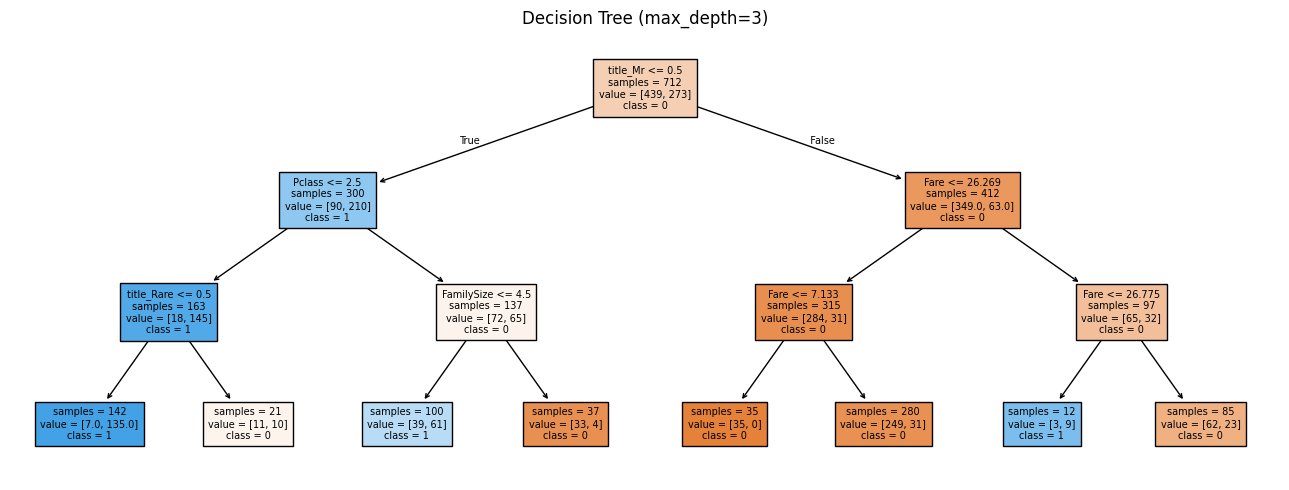

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize=(13, 5))
plot_tree(
    DecisionTreeClassifier(max_depth=3, random_state=RS).fit(X_tr, y_tr),
    feature_names=list(X.columns), class_names=["0", "1"],
    filled=True, impurity=False, fontsize=7,
)
plt.title("Decision Tree (max_depth=3)")
plt.tight_layout(); plt.show()

## 2) XGBoost

핵심 하이퍼파라미터입니다.

| 파라미터 | 의미 | 영향 |
|----------|------|------|
| `n_estimators` | 트리(부스팅 라운드) 개수 | 많을수록 표현력↑, 과적합 위험↑ |
| `learning_rate` | 각 트리 기여 축소($\eta$) | 작을수록 안정적이나 더 많은 트리 필요 |
| `max_depth` | 트리 최대 깊이 | 클수록 복잡한 상호작용 학습 |
| `subsample` | 행 샘플링 비율 | <1이면 과적합 완화 |
| `colsample_bytree` | 열 샘플링 비율 | <1이면 과적합 완화 |
| `reg_lambda` | L2 정규화 | 클수록 단순한 모델 |

**조기 종료(early stopping)**: 검증 점수가 일정 라운드 동안 개선되지 않으면 학습을 멈춰, 최적 트리 수를 자동으로 찾습니다.
XGBoost에서는 `early_stopping_rounds`와 `eval_metric`을 **생성자에** 지정하고, `fit`에 `eval_set`을 넘깁니다.

In [6]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric="logloss",
    early_stopping_rounds=40,
    random_state=RS,
    n_jobs=-1,
)
xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

print("최적 트리 수(best_iteration):", xgb.best_iteration)
proba_xgb = xgb.predict_proba(X_va)[:, 1]
pred_xgb = (proba_xgb >= 0.5).astype(int)
print("XGB  Accuracy: %.3f | F1: %.3f | ROC-AUC: %.3f"
      % (accuracy_score(y_va, pred_xgb), f1_score(y_va, pred_xgb), roc_auc_score(y_va, proba_xgb)))

최적 트리 수(best_iteration): 59


XGB  Accuracy: 0.816 | F1: 0.740 | ROC-AUC: 0.859


## 3) LightGBM

LightGBM은 잎 단위(leaf-wise)로 성장하므로 **`num_leaves`** 가 복잡도의 핵심입니다.
(`max_depth`로 직접 제한하기보다 `num_leaves`와 `min_child_samples`로 조절)

| 파라미터 | 의미 |
|----------|------|
| `num_leaves` | 한 트리의 최대 잎 수 — 클수록 복잡(과적합 위험) |
| `min_child_samples` | 잎이 되기 위한 최소 샘플 수 — 클수록 보수적 |
| `learning_rate`, `n_estimators` | XGBoost와 동일 개념 |
| `subsample`, `colsample_bytree` | 행/열 샘플링 |

API는 조금 다릅니다: 조기 종료·로그 억제를 **콜백(callbacks)** 으로 전달합니다.

In [7]:
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RS,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    eval_metric="binary_logloss",
    callbacks=[early_stopping(40, verbose=False), log_evaluation(0)],
)

print("최적 트리 수(best_iteration_):", lgbm.best_iteration_)
proba_lgb = lgbm.predict_proba(X_va)[:, 1]
pred_lgb = (proba_lgb >= 0.5).astype(int)
print("LGBM Accuracy: %.3f | F1: %.3f | ROC-AUC: %.3f"
      % (accuracy_score(y_va, pred_lgb), f1_score(y_va, pred_lgb), roc_auc_score(y_va, proba_lgb)))

최적 트리 수(best_iteration_): 38
LGBM Accuracy: 0.849 | F1: 0.791 | ROC-AUC: 0.844


### LightGBM 하이퍼파라미터 지도

설정이 많아 보이지만 **역할별로 묶으면** 외울 게 줄어듭니다. (괄호는 네이티브 API에서의 이름)

**① 학습 제어**

| 파라미터 | 역할 |
|---|---|
| `n_estimators` (`num_boost_round`) | 트리(부스팅 라운드) 수 |
| `learning_rate` | 트리당 기여도(보폭) |
| `early_stopping` 콜백 | 검증 점수가 안 오르면 중단 |

**② 트리 구조·복잡도**

| 파라미터 | 역할 |
|---|---|
| `num_leaves` | 한 트리의 최대 잎 수 — leaf-wise의 핵심 손잡이 |
| `max_depth` | 최대 깊이(-1=무제한). `num_leaves`의 보조 상한 |
| `min_child_samples` (`min_data_in_leaf`) | 잎이 되려면 필요한 최소 샘플 |
| `min_split_gain` (`min_gain_to_split`) | 분기에 필요한 최소 이득 |

**③ 샘플링·정규화 (과적합 억제)**

| 파라미터 | 역할 |
|---|---|
| `subsample`+`subsample_freq` (`bagging_fraction`/`_freq`) | 행 샘플링 |
| `colsample_bytree` (`feature_fraction`) | 열 샘플링 |
| `reg_alpha` (`lambda_l1`) · `reg_lambda` (`lambda_l2`) | L1·L2 정규화 |

**④ 기타**: `objective`(binary/multiclass/regression), `metric`, `class_weight`·`scale_pos_weight`(불균형), `random_state`, `n_jobs`, `verbose`.

### 과적합 ↔ 과소적합, 어느 손잡이를 돌릴까

학습 점수는 높은데 검증이 낮으면(과적합) 모델을 **단순하게**, 둘 다 낮으면(과소적합) **복잡하게** 만듭니다.

| 손잡이 | 과적합이면 (단순하게) | 과소적합이면 (복잡하게) |
|---|---|---|
| `num_leaves` | ↓ | ↑ |
| `min_child_samples` | ↑ | ↓ |
| `reg_alpha` / `reg_lambda` | ↑ | ↓ |
| `feature_fraction`·`bagging_fraction` | ↓ | 1에 가깝게 ↑ |
| `learning_rate` / `n_estimators` | lr ↓ + 트리 ↑ | lr ↑ 또는 트리 ↑ |

하나만 고르라면 **`num_leaves`** 입니다. 너무 키우면 leaf-wise 특성상 금세 과적합합니다.

### 범주형 변수를 그대로 쓰기

실습 내내 `get_dummies`로 원-핫 인코딩을 했지만, **LightGBM은 범주형을 직접** 받을 수 있습니다.
열의 dtype을 `category`로 바꿔 주면 자동으로 범주형으로 인식해, 원-핫 없이 분기합니다(고유값이 많은 범주에서 특히 유리).

In [8]:
cat_X = titanic[["Pclass", "Age", "SibSp", "Parch", "Fare", "Gender", "Embarked"]].copy()
cat_X["Age"] = cat_X["Age"].fillna(cat_X["Age"].median())
cat_X["Embarked"] = cat_X["Embarked"].fillna(cat_X["Embarked"].mode()[0])
for c in ["Gender", "Embarked"]:
    cat_X[c] = cat_X[c].astype("category")     # category dtype → 자동으로 범주형 처리

cx_tr, cx_va, cy_tr, cy_va = train_test_split(cat_X, y, test_size=0.2, stratify=y, random_state=RS)
cat_model = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                           random_state=RS, n_jobs=-1, verbose=-1)
cat_model.fit(cx_tr, cy_tr)                     # 원-핫 인코딩 없이 그대로 학습
print("범주형을 그대로 넣은 ROC-AUC: %.3f" % roc_auc_score(cy_va, cat_model.predict_proba(cx_va)[:, 1]))
print("자동 인식된 범주형 열:", [c for c in cat_X.columns if str(cat_X[c].dtype) == "category"])

범주형을 그대로 넣은 ROC-AUC: 0.808
자동 인식된 범주형 열: ['Gender', 'Embarked']


### 네이티브 API와 교차검증·콜백

지금까지는 scikit-learn 호환 API(`LGBMClassifier`)를 썼습니다. LightGBM에는 **네이티브 API**도 있어서,
데이터를 `lgb.Dataset`으로 감싸고 `params` 딕셔너리로 설정한 뒤 `lgb.train`으로 학습합니다(대용량에서 메모리·속도 유리).

- `lgb.cv(...)`: 교차검증을 한 줄로. 라운드별 fold 평균 점수를 돌려줍니다.
- **콜백**으로 학습을 제어합니다: `early_stopping`(조기 종료), `log_evaluation`(로그 간격),
  `reset_parameter`(학습률 스케줄). 예) `callbacks=[lgb.reset_parameter(learning_rate=lambda it: 0.1 * 0.99 ** it)]`

In [9]:
import lightgbm as lgb

dtrain = lgb.Dataset(X_tr, y_tr)
dvalid = lgb.Dataset(X_va, y_va, reference=dtrain)

# 네이티브 파라미터 이름 사용 (sklearn 별칭과 1:1 대응)
params = {
    "objective": "binary", "metric": "auc",
    "num_leaves": 31, "learning_rate": 0.05,
    "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1,
    "seed": RS, "verbose": -1,
}
booster = lgb.train(
    params, dtrain, num_boost_round=500, valid_sets=[dvalid],
    callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(0)],
)
print("best_iteration:", booster.best_iteration,
      "| valid AUC: %.3f" % roc_auc_score(y_va, booster.predict(X_va)))

# 교차검증도 네이티브로 한 줄
cv = lgb.cv(params, dtrain, num_boost_round=500, nfold=5, stratified=True,
            callbacks=[lgb.early_stopping(40, verbose=False)], seed=RS)
print("5-fold CV AUC: %.4f (best round=%d)" % (max(cv["valid auc-mean"]), len(cv["valid auc-mean"])))

best_iteration: 27 | valid AUC: 0.853


5-fold CV AUC: 0.8946 (best round=101)


### 사용자 정의 평가지표

내장 지표(`auc`, `binary_logloss` …) 외에 **직접 만든 지표**로 검증·조기 종료를 할 수 있습니다.
함수는 `(정답, 예측확률)`을 받아 `(이름, 값, 클수록_좋은가)`를 돌려주면 됩니다. 아래는 F1을 검증 지표로 쓰는 예입니다.

In [10]:
def f1_eval(y_true, y_pred):
    # y_pred는 예측 확률(이진). 0.5 기준으로 라벨화해 F1을 계산
    return "f1", f1_score(y_true, (y_pred >= 0.5).astype(int)), True   # (이름, 값, 클수록 좋음)

custom = LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                        random_state=RS, n_jobs=-1, verbose=-1)
custom.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric=f1_eval,
           callbacks=[early_stopping(40, verbose=False), log_evaluation(0)])
print("F1 기준 최적 트리 수:", custom.best_iteration_)
print("검증 F1:", round(custom.best_score_["valid_0"]["f1"], 4))

F1 기준 최적 트리 수: 22
검증 F1: 0.7874


## 4) 모델 평가

분류 성능은 한 숫자로 말하기 어렵습니다. 목적에 따라 여러 지표를 함께 봅니다.

| 지표 | 정의 | 언제 중요한가 |
|------|------|---------------|
| Accuracy | 전체 중 맞춘 비율 | 클래스가 균형일 때 |
| Precision | 양성 *예측* 중 실제 양성 | 거짓 양성 비용이 클 때 |
| Recall | 실제 양성 중 *찾아낸* 비율 | 놓치는 비용이 클 때(진단 등) |
| F1 | Precision·Recall 조화평균 | 둘의 균형 |
| ROC-AUC | 임계값과 무관한 **확률 순위** 품질 | 모델 비교·불균형 데이터 |

`predict`는 임계값 0.5로 라벨을 내지만, `predict_proba`로 확률을 얻어 임계값을 조절할 수 있습니다.

In [11]:
# 혼동행렬 (LightGBM 기준)
cm = confusion_matrix(y_va, pred_lgb)
cm_df = pd.DataFrame(cm, index=["실제 0(사망)", "실제 1(생존)"], columns=["예측 0", "예측 1"])
print("[혼동행렬 — LightGBM]")
display(cm_df)

print("\n[분류 리포트 — LightGBM]")
print(classification_report(y_va, pred_lgb, digits=3))

# 두 모델 지표 비교표
def metrics_row(name, y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return {
        "model": name,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "ROC-AUC": roc_auc_score(y_true, proba),
    }

compare = pd.DataFrame([
    metrics_row("XGBoost", y_va, proba_xgb),
    metrics_row("LightGBM", y_va, proba_lgb),
]).set_index("model").round(3)
print("[모델 비교]")
display(compare)

[혼동행렬 — LightGBM]


,예측 0,예측 1
실제 0(사망),101,9
실제 1(생존),18,51



[분류 리포트 — LightGBM]
              precision    recall  f1-score   support

           0      0.849     0.918     0.882       110
           1      0.850     0.739     0.791        69

    accuracy                          0.849       179
   macro avg      0.849     0.829     0.836       179
weighted avg      0.849     0.849     0.847       179

[모델 비교]


,Accuracy,Precision,Recall,F1,ROC-AUC
model,,,,,
XGBoost,0.816,0.81,0.681,0.740,0.859
LightGBM,0.849,0.85,0.739,0.791,0.844


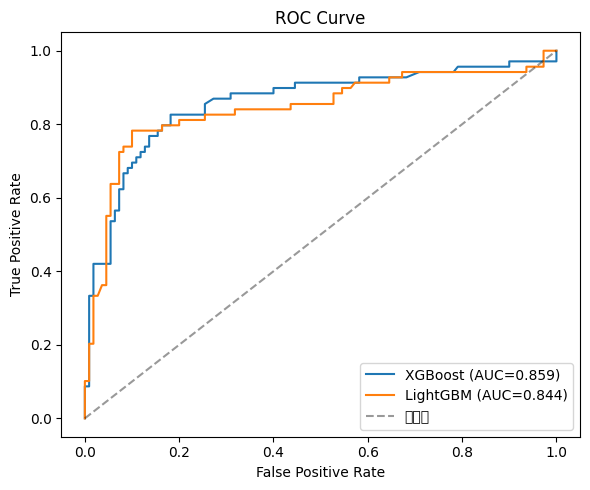

In [12]:
# ROC 곡선 비교
plt.figure(figsize=(6, 5))
for name, proba in [("XGBoost", proba_xgb), ("LightGBM", proba_lgb)]:
    fpr, tpr, _ = roc_curve(y_va, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_va, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="무작위")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(); plt.tight_layout(); plt.show()

## 5) 교차검증 (Cross-Validation)

단일 hold-out 점수는 **어떻게 쪼갰는지(우연)** 에 흔들립니다.
**K-Fold 교차검증**은 데이터를 K등분해 번갈아 검증하고 평균±표준편차로 성능을 보고하므로 더 신뢰할 수 있습니다.
분류에서는 각 fold의 클래스 비율을 유지하는 `StratifiedKFold`를 씁니다.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
lgbm_cv = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                         random_state=RS, n_jobs=-1, verbose=-1)
auc_scores = cross_val_score(lgbm_cv, X, y, cv=cv, scoring="roc_auc")
print("Fold별 AUC:", np.round(auc_scores, 3))
print("교차검증 ROC-AUC: %.3f ± %.3f" % (auc_scores.mean(), auc_scores.std()))

Fold별 AUC: [0.898 0.896 0.845 0.873 0.889]
교차검증 ROC-AUC: 0.880 ± 0.019


## 6) 피처 중요도

중요도에는 **두 종류**가 있고, 무엇을 보느냐에 따라 순위가 달라질 수 있습니다.

- **`split`(빈도)**: 그 변수가 분기에 **몇 번 쓰였는지**. `feature_importances_`의 기본값입니다.
- **`gain`(이득)**: 그 변수의 분기가 **손실을 얼마나 줄였는지**. 보통 더 의미 있는 척도입니다.

해석의 출발점일 뿐, 상관된 변수끼리는 중요도가 나뉠 수 있으니 *인과*로 읽으면 안 됩니다.

[split vs gain — 순위가 다를 수 있다]


,split,gain
title_Mr,28,1821.4
Fare,423,866.3
Pclass,57,556.2
Age,257,468.6
Gender_male,12,416.0
FamilySize,66,356.7
title_Miss,12,88.7
title_Rare,13,85.3
title_Mrs,13,73.8
Embarked_S,49,61.1


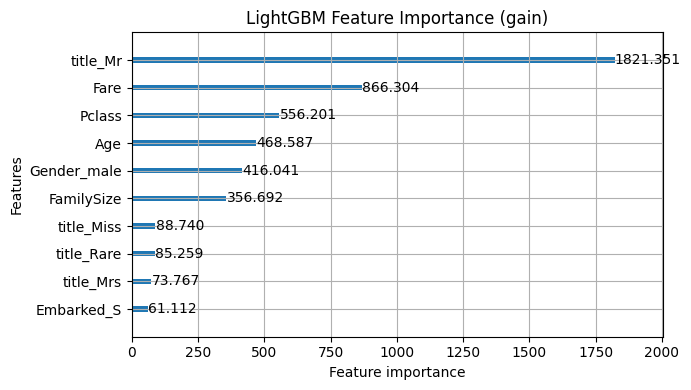

In [14]:
imp = pd.DataFrame({
    "split": lgbm.booster_.feature_importance("split"),
    "gain": lgbm.booster_.feature_importance("gain"),
}, index=X.columns).sort_values("gain", ascending=False)
print("[split vs gain — 순위가 다를 수 있다]")
display(imp.head(10).round(1))

# gain 기준 시각화 (lgb.plot_importance 사용)
import lightgbm as lgb
ax = lgb.plot_importance(lgbm, importance_type="gain", max_num_features=10, figsize=(7, 4))
ax.set_title("LightGBM Feature Importance (gain)")
plt.tight_layout(); plt.show()

### 트리 한 그루 들여다보기

부스팅 모델은 트리 수백 그루의 합이지만, **한 그루**를 꺼내 보면 모델이 어떤 분기를 배웠는지 볼 수 있습니다.
`lgb.plot_tree`로 그립니다(graphviz 필요). 잎의 `leaf_value`가 그 경로가 최종 점수에 더하는 기여분입니다.

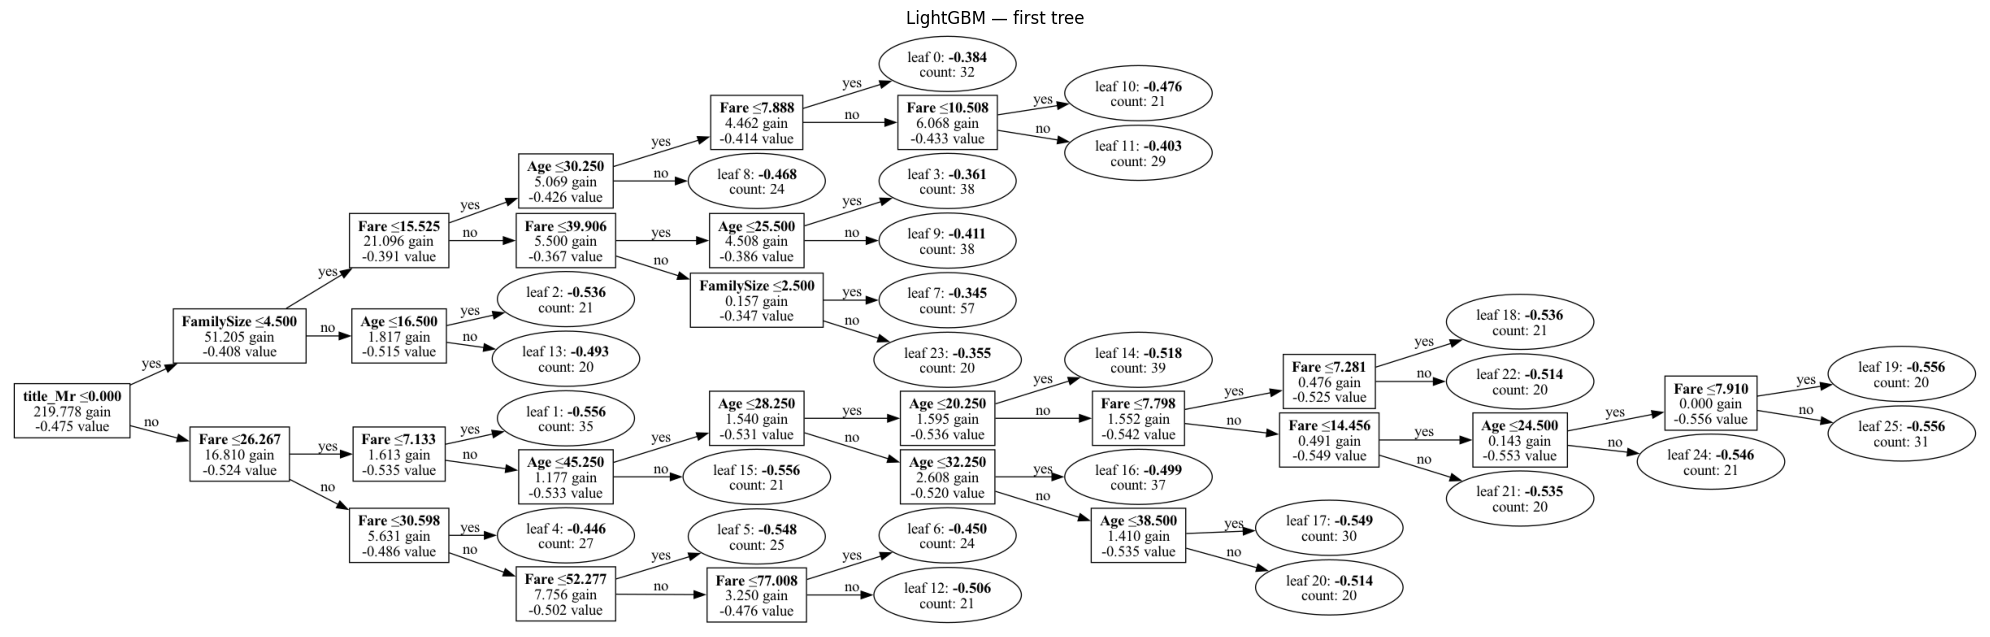

In [15]:
import lightgbm as lgb

ax = lgb.plot_tree(lgbm, tree_index=0, figsize=(20, 7),
                   show_info=["split_gain", "internal_value", "leaf_count"])
ax.set_title("LightGBM — first tree")
plt.tight_layout(); plt.show()

## 7) 하이퍼파라미터 튜닝

성능을 끌어올리는 마지막 단계입니다. **교차검증 점수**를 기준으로 파라미터 조합을 탐색합니다.

- `GridSearchCV`: 격자(grid)의 모든 조합을 시도 — 작은 공간에 적합.
- `RandomizedSearchCV` / Optuna: 공간이 넓을 때 무작위·베이지안 탐색이 효율적.

여기서는 작은 격자로 `GridSearchCV`를 시연합니다. (조합 수 × fold 수만큼 학습하므로 비용에 유의)

In [16]:
param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31],
}
grid = GridSearchCV(
    LGBMClassifier(random_state=RS, n_jobs=-1, verbose=-1),
    param_grid, cv=3, scoring="roc_auc", n_jobs=-1,
)
grid.fit(X, y)
print("최적 파라미터:", grid.best_params_)
print("최적 교차검증 AUC: %.3f" % grid.best_score_)

최적 파라미터: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 15}
최적 교차검증 AUC: 0.863


### 더 똑똑한 탐색: Optuna

`GridSearchCV`는 격자의 **모든 조합**을 시도해 느립니다. **Optuna**는 이전 시도 결과를 보고 유망한 영역을
**베이지안**으로 탐색해, 더 적은 횟수로 좋은 조합을 찾습니다.

- `objective(trial)`: `trial.suggest_*`로 탐색 범위를 정하고 교차검증 점수를 돌려줍니다.
- `study.optimize(objective, n_trials=...)`로 반복합니다(시드를 고정하면 재현 가능).

In [17]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # 탐색 로그 억제

def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 63),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 40),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
    )
    model = LGBMClassifier(random_state=RS, n_jobs=-1, verbose=-1, **params)
    return cross_val_score(model, X, y, cv=3, scoring="roc_auc").mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=RS))
study.optimize(objective, n_trials=20, show_progress_bar=False)

print("Optuna 최적 AUC: %.4f  (%d trials)" % (study.best_value, len(study.trials)))
print("최적 파라미터:", study.best_params)

Optuna 최적 AUC: 0.8726  (20 trials)
최적 파라미터: {'n_estimators': 319, 'learning_rate': 0.017398074711291726, 'num_leaves': 62, 'min_child_samples': 34, 'subsample': 0.9757995766256756, 'colsample_bytree': 0.9579309401710595}


## 8) 실전 워크플로 ① — 분류 제출 (diabetes)

실전 과제는 보통 **정답이 있는 `train`** 과 **정답이 없는 `test`** 로 나뉘어 주어집니다.
`train`으로 학습한 모델로 `test`를 예측해 **제출 파일**을 만드는 것이 목표입니다.

- 데이터: `diabetes_train.csv`(`Outcome` 포함) → `diabetes_test.csv`(`Outcome` 없음)
- 식별자 `id`는 피처에서 제외하되, 제출 파일에는 그대로 사용
- 분류 제출은 보통 **예측 확률** 또는 **0/1 라벨**을 요구합니다(문제 지시에 따름)

In [18]:
dtr = pd.read_csv(DE + "diabetes_train.csv")
dte = pd.read_csv(DE + "diabetes_test.csv")
print("train:", dtr.shape, "| test:", dte.shape)

X_d = dtr.drop(columns=["id", "Outcome"])
y_d = dtr["Outcome"]
X_d_test = dte.drop(columns=["id"])

# 제출 전, 교차검증으로 기대 성능을 먼저 확인
clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
                    random_state=RS, n_jobs=-1)
cv_auc = cross_val_score(clf, X_d, y_d, cv=5, scoring="roc_auc")
print("diabetes 교차검증 AUC: %.3f ± %.3f" % (cv_auc.mean(), cv_auc.std()))

# 전체 train으로 재학습 후 test 예측
clf.fit(X_d, y_d)
proba = clf.predict_proba(X_d_test)[:, 1]
submission = pd.DataFrame({
    "id": dte["id"],
    "pred_proba": proba.round(4),
    "pred": (proba >= 0.5).astype(int),
})
submission.to_csv("submission_diabetes.csv", index=False)
print("저장 완료: submission_diabetes.csv | 양성 예측 비율: %.3f" % submission["pred"].mean())
display(submission.head())

train: (576, 10) | test: (192, 9)


diabetes 교차검증 AUC: 0.834 ± 0.027
저장 완료: submission_diabetes.csv | 양성 예측 비율: 0.354


,id,pred_proba,pred
0,258,0.7408,1
1,220,0.8333,1
2,438,0.0028,0
3,130,0.9491,1
4,730,0.1671,0


## 9) 실전 워크플로 ② — 회귀 (gas)

목표 변수가 연속형이면 **회귀**입니다. 모델은 `...Regressor`, 평가지표는 RMSE·MAE·R²를 씁니다.

- 데이터: `gas_train.csv`(`총가스사용량` 포함) → `gas_test.csv`
- 범주형 `시군구명`은 원-핫 인코딩하되, **train/test 열을 일치**시켜야 합니다(`reindex`).

| 지표 | 의미 |
|------|------|
| RMSE | 큰 오차에 더 민감한 평균 오차(목표 단위) |
| MAE | 평균 절대 오차(이상치에 덜 민감) |
| R² | 분산 설명력(1에 가까울수록 좋음) |

In [19]:
gtr = pd.read_csv(DE + "gas_train.csv")
gte = pd.read_csv(DE + "gas_test.csv")

X_g = pd.get_dummies(gtr.drop(columns=["총가스사용량"]), columns=["시군구명"])
y_g = gtr["총가스사용량"]
# test를 같은 열 구성으로 맞춤 (없는 지역 열은 0으로 채움)
X_g_test = pd.get_dummies(gte, columns=["시군구명"]).reindex(columns=X_g.columns, fill_value=0)

# 검증으로 성능 확인
Xg_tr, Xg_va, yg_tr, yg_va = train_test_split(X_g, y_g, test_size=0.2, random_state=RS)
reg = LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31,
                    random_state=RS, n_jobs=-1, verbose=-1)
reg.fit(Xg_tr, yg_tr)
pred_va = reg.predict(Xg_va)
print("RMSE: %.1f | MAE: %.1f | R²: %.3f"
      % (root_mean_squared_error(yg_va, pred_va), mean_absolute_error(yg_va, pred_va), r2_score(yg_va, pred_va)))

# 전체 train 재학습 후 test 예측 → 제출
reg.fit(X_g, y_g)
gas_pred = reg.predict(X_g_test)
gas_sub = pd.DataFrame({"pred_총가스사용량": gas_pred.round(1)})
gas_sub.to_csv("submission_gas.csv", index=False)
print("저장 완료: submission_gas.csv")
display(gas_sub.head())

RMSE: 1030.8 | MAE: 545.8 | R²: 0.689


저장 완료: submission_gas.csv


,pred_총가스사용량
0,10092.3
1,10730.1
2,8929.3
3,10092.3
4,11298.5


## 10) 다중 분류 (multiclass)

타깃이 3개 이상의 범주이면 **다중 분류**입니다(예: 등급 A/B/C 예측). 이진 분류와 무엇이 달라지는지 짚어 둡니다.

| 항목 | 이진 분류 | 다중 분류 |
|------|-----------|-----------|
| LightGBM `objective` | `binary` | `multiclass` (자동 추론도 됨) |
| `predict_proba` | 양성 확률 1개 | **클래스별 확률 행렬** (열 = 클래스 수) |
| 대표 지표 | ROC-AUC, F1 | **F1-macro** (클래스별 F1의 단순 평균) |
| 불균형 보정 | `scale_pos_weight` | **`class_weight="balanced"`** |

**F1-macro**는 클래스 크기와 무관하게 각 클래스의 F1을 동일 가중으로 평균하므로, **소수 클래스의 성능까지 반영**합니다.
앞서 만든 Titanic 피처(`X`)를 재사용해, 이번에는 **객실 등급 `Pclass`(1·2·3등급)** 를 맞혀 봅니다.

In [20]:
# 앞서 만든 X(생존 예측용 피처)에서 Pclass를 타깃으로 분리
X_multi = X.drop(columns=["Pclass"])
y_multi = titanic["Pclass"]
print("클래스 분포:\n", y_multi.value_counts().sort_index())

Xm_tr, Xm_va, ym_tr, ym_va = train_test_split(
    X_multi, y_multi, test_size=0.2, stratify=y_multi, random_state=RS)

mclf = LGBMClassifier(
    objective="multiclass",
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    class_weight="balanced",     # 클래스 불균형 보정
    random_state=RS, n_jobs=-1, verbose=-1,
)
mclf.fit(Xm_tr, ym_tr)
pred_m = mclf.predict(Xm_va)

print("\npredict_proba 형태:", mclf.predict_proba(Xm_va).shape, "(행=샘플, 열=클래스 수)")
print("F1-macro: %.3f" % f1_score(ym_va, pred_m, average="macro"))
print("\n[분류 리포트]")
print(classification_report(ym_va, pred_m, digits=3))

클래스 분포:
 Pclass
1    216
2    184
3    491
Name: count, dtype: int64



predict_proba 형태: (179, 3) (행=샘플, 열=클래스 수)
F1-macro: 0.915

[분류 리포트]
              precision    recall  f1-score   support

           1      1.000     0.907     0.951        43
           2      0.861     0.838     0.849        37
           3      0.923     0.970     0.946        99

    accuracy                          0.927       179
   macro avg      0.928     0.905     0.915       179
weighted avg      0.929     0.927     0.927       179



## 생각해보기

1. `learning_rate`를 0.05 → 0.2로 키우면 `best_iteration`(최적 트리 수)은 어떻게 변할까요? 왜 그럴까요?
2. LightGBM의 `num_leaves`를 키우면서 `min_child_samples`를 그대로 두면 어떤 위험이 있나요?
3. Titanic 분류에서 임계값을 0.5 대신 0.3으로 낮추면 Precision/Recall은 각각 어떻게 변하나요? 어떤 상황에서 그렇게 할까요?
4. 피처 중요도 1위가 `Fare`였습니다. `Fare`를 제거하면 AUC가 얼마나 떨어지는지 확인하고, 그 의미를 해석해 보세요.
5. diabetes 데이터에는 `Glucose`, `BloodPressure` 등에 0이 섞여 있습니다(생리학적으로 불가능). 이를 결측으로 보고 대치하면 성능이 달라질까요?
6. 회귀(gas)에서 RMSE와 MAE가 크게 차이 난다면, 데이터에 대해 무엇을 시사하나요?
7. 다중 분류에서 `class_weight="balanced"`를 빼면 F1-macro와 클래스별 recall이 어떻게 달라지나요? 어떤 클래스가 손해를 볼까요?